# E-Commerce Retail Data Analytics & Revenue prediction Using machine learning
 **Comprehensive Analysis and Step-By-Step Breakdown**

This document has been thoroughly enhanced to provide deep business intelligence insights. It bridges the gap between raw code and actionable business metrics.

It is an **integrated Data Science and Business Intelligence framework** for performing large-scale e-commerce sales analytics and predictive modeling. Built around real-world example using transaction datasets (such as the UCI Online Retail II dataset spanning over 1 million transactions), it demonstrates how online retailers can uncover product performance, regional demand, customer purchasing behaviors, and future revenue streams without requiring expensive enterprise infrastructure

---
### 💡 What We Are Doing
We are examining a massive e-commerce dataset (over 500,000 rows of transactions). We will:
1. **Clean & Aggregate:** Use SQL to handle the large data efficiently without crashing memory.
2. **Visualize & Analyze:** Generate 5 crucial business graphs and explain exactly what they mean for the business.
3. **Machine Learning:** Predict future revenue patterns using predictive regression and classification models.


In [28]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


###Aggregation at Scale (SQL) & Feature Engineering
**Why are we doing this?**
When dealing with hundreds of thousands of rows, traditional loops in Python are too slow. We use an in-memory SQL database (SQLite) to rapidly filter out bad data (like negative prices or quantities) and calculate total revenue (`Quantity * UnitPrice`).

**What the code does:**
It filters out missing IDs, removes canceled orders (where invoices start with 'C'), and calculates the financial baseline: `Revenue`.


In [29]:
print("Ingesting data & Executing SQL Data Hygiene...")
con = sqlite3.connect(':memory:')
raw_df = pd.read_csv('online_retail.csv', encoding='unicode_escape')
raw_df.to_sql('raw_sales', con, index=False)

query_clean_data = '''
CREATE TABLE clean_sales AS
SELECT
    InvoiceNo, StockCode, Description,
    CAST(Quantity AS INTEGER) AS Quantity,
    InvoiceDate,
    CAST(UnitPrice AS REAL) AS UnitPrice,
    CustomerID, Country,
    (CAST(Quantity AS INTEGER) * CAST(UnitPrice AS REAL)) AS Revenue
FROM raw_sales
WHERE CustomerID IS NOT NULL
  AND CustomerID != ''
  AND InvoiceNo NOT LIKE 'C%'
  AND CAST(Quantity AS INTEGER) > 0
  AND CAST(UnitPrice AS REAL) > 0;
'''
con.execute(query_clean_data)
df_clean = pd.read_sql_query("SELECT * FROM clean_sales", con)
con.close()
print(f"Data cleaned! Validated data shape: {df_clean.shape[0]:,} rows.")
print(df_clean.head(5))


Ingesting data & Executing SQL Data Hygiene...
Data cleaned! Validated data shape: 397,884 rows.
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  


## Datetime Manipulation:

Before we visualize the data, we must extract intelligent indicators from our raw timestamp (`InvoiceDate`).
**Why?** A date like '2011-12-01 08:26:00' is hard to plot. By breaking it into `Month`, `Hour`, and `Day of Week`, we can analyze seasonal trends, peak shopping hours, and active days.


In [30]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Extracting Time Vectors
df_clean['Month_Num'] = df_clean['InvoiceDate'].dt.month
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Month_Year'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

print("Datetime features successfully extracted.")
print(df_clean['Month_Num'].head(1))
print(df_clean['Hour'].head(1))
print(df_clean['DayOfWeek'].head(1))
print(df_clean['Month_Year'].head(1))
print("---")
print(df_clean.head(5))

Datetime features successfully extracted.
0    12
Name: Month_Num, dtype: int32
0    8
Name: Hour, dtype: int32
0    Wednesday
Name: DayOfWeek, dtype: object
0    2010-12
Name: Month_Year, dtype: object
---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.3

# Business Revenue Trajectory (Monthly Trend):

This line chart displays the total revenue generated by the business every month.
**Why it is useful:** It helps executives identify seasonality. Typically, e-commerce businesses experience a massive spike perfectly aligned with the Q4 Holiday Season (November/December). If you see a dip, the business needs to investigate supply chain issues or marketing failures during that month.


Monthly Revenue
  Month_Year     Revenue
0    2010-12  572713.890
1    2011-01  569445.040
2    2011-02  447137.350
3    2011-03  595500.760
4    2011-04  469200.361
5    2011-05  678594.560
6    2011-06  661213.690
7    2011-07  600091.011
8    2011-08  645343.900
9    2011-09  952838.382



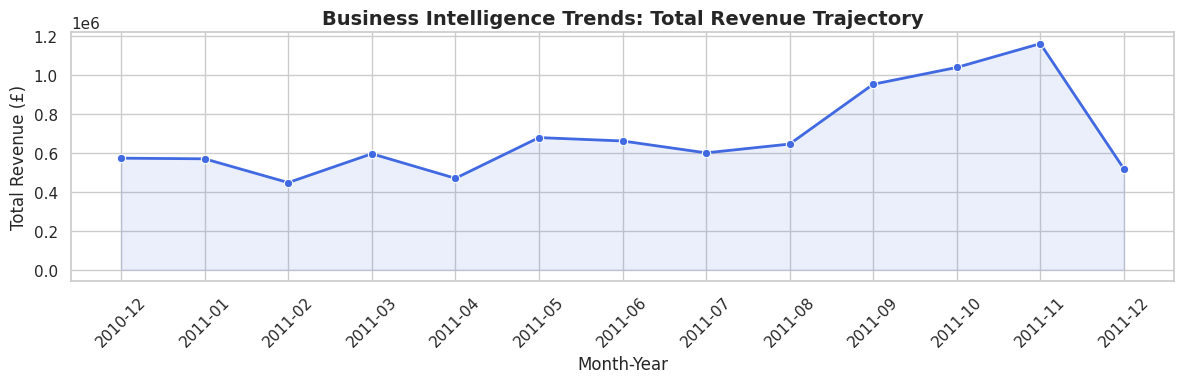

In [31]:
monthly_rev = df_clean.groupby('Month_Year')['Revenue'].sum().reset_index()
print("Monthly Revenue")
print(monthly_rev.head(10))
print()

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly_rev, x='Month_Year', y='Revenue', marker='o', lw=2, color='royalblue')
plt.title('Business Intelligence Trends: Total Revenue Trajectory', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.fill_between(monthly_rev['Month_Year'], monthly_rev['Revenue'], alpha=0.1, color='royalblue')
plt.tight_layout()
plt.show()


## Top 10 Best-Selling Products

A bar chart ranking the highest revenue-generating products in the store's inventory.
**Why it is useful:** Inventory management is crucial. The top products drive the majority of the profit. This chart tells the purchasing department exactly which items they MUST never allow to go out of stock.


Top 10 best product
                          Description    Revenue
0         PAPER CRAFT , LITTLE BIRDIE  168469.60
1            REGENCY CAKESTAND 3 TIER  142592.95
2  WHITE HANGING HEART T-LIGHT HOLDER  100448.15
3             JUMBO BAG RED RETROSPOT   85220.78
4      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
5                             POSTAGE   77803.96
6                       PARTY BUNTING   68844.33
7       ASSORTED COLOUR BIRD ORNAMENT   56580.34
8                              Manual   53779.93
9                  RABBIT NIGHT LIGHT   51346.20



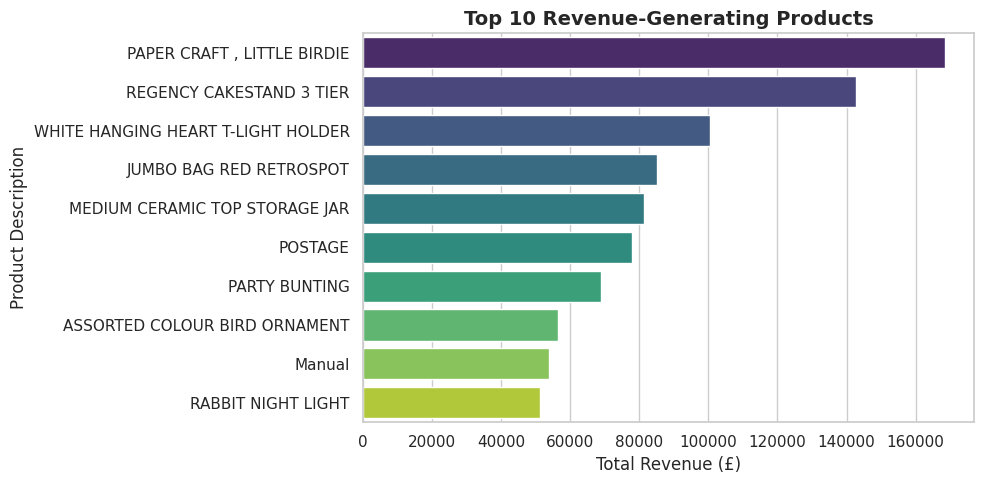

In [32]:
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print(f"Top 10 best product")
print(top_products.head(10))
print()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, y='Description', x='Revenue', palette='viridis')
plt.title('Top 10 Revenue-Generating Products', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()


## Geographical Sales Distribution (Top 10 Countries):

 A breakdown of total revenue generated by country.
**Why it is useful:** It reveals the business's core market. If 90% of the sales come from the UK, the company is highly localized and exposed to regional economic downturns. This insight pushes the marketing team to invest in broader global expansion campaigns.


Top 10 Countries
          Country      Revenue
0  United Kingdom  7308391.554
1     Netherlands   285446.340
2            EIRE   265545.900
3         Germany   228867.140
4          France   209024.050
5       Australia   138521.310
6           Spain    61577.110
7     Switzerland    56443.950
8         Belgium    41196.340
9          Sweden    38378.330



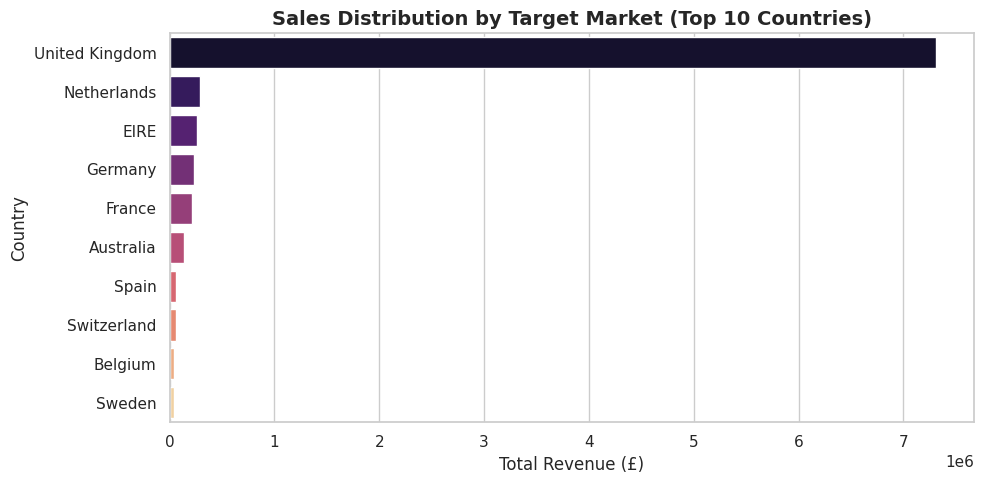

In [33]:
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print("Top 10 Countries")
print(top_countries.head(10))
print()

# Create a bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries, y='Country', x='Revenue', palette='magma')
plt.title('Sales Distribution by Target Market (Top 10 Countries)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


### Consumer Shopping Heatmap (Hour vs Day)
**What you are seeing:** A grid where color intensity shows the busiest shopping hours (Y-axis) per day of the week (X-axis).
**Why it is useful:** This is critical for Server Scaling and Customer Support. If the heatmap is darkest at "Thursday 2:00 PM", the engineering team must scale up AWS servers at that exact time to prevent crashes, and the support center needs peak staff on duty.


Customer Shopping hours
DayOfWeek  Friday  Monday  Sunday  Thursday  Tuesday  Wednesday
Hour                                                           
6             NaN     NaN     NaN       1.0      NaN        NaN
7             6.0     4.0     NaN       9.0      5.0        5.0
8           120.0    85.0     NaN     119.0    115.0      116.0
9           266.0   251.0     2.0     294.0    290.0      290.0
10          410.0   322.0   225.0     442.0    393.0      434.0
11          364.0   340.0   385.0     370.0    405.0      413.0
12          463.0   480.0   459.0     586.0    531.0      611.0
13          397.0   436.0   356.0     479.0    475.0      493.0
14          361.0   374.0   306.0     445.0    371.0      417.0
15          253.0   317.0   330.0     421.0    345.0      371.0

DayOfWeek  Monday  Tuesday  Wednesday  Thursday  Friday  Sunday
Hour                                                           
6             NaN      NaN        NaN       1.0     NaN     NaN
7             4

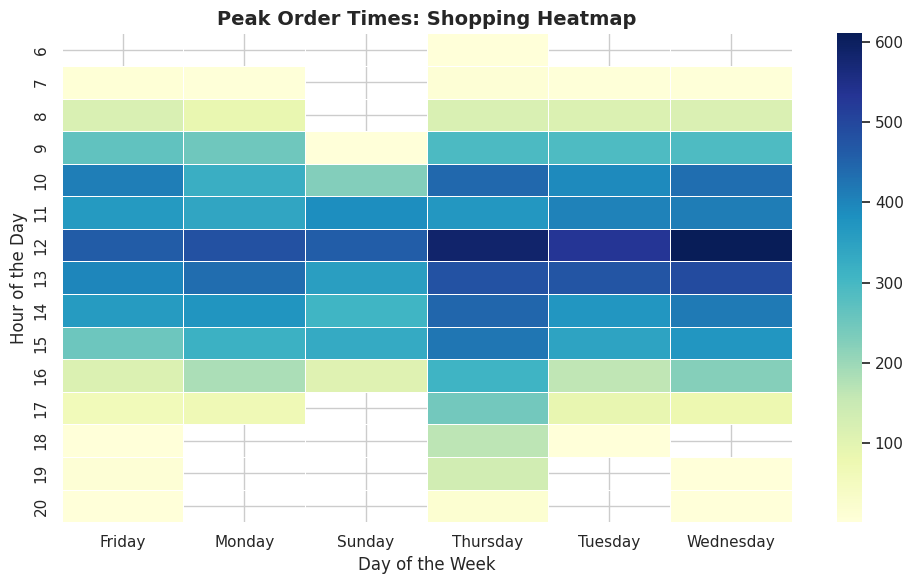

In [34]:
heatmap_data = df_clean.groupby(['Hour', 'DayOfWeek'])['InvoiceNo'].nunique().unstack()
print("Customer Shopping hours")
print(heatmap_data.head(10))
print()
# Reorder days logically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
existing_order = [day for day in days_order if day in heatmap_data.columns]
heatmap_datas = heatmap_data[days_order]
print(heatmap_datas.head(10))
print()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, linewidths=0.5)
plt.title('Peak Order Times: Shopping Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.tight_layout()
plt.show()


###  Customer Purchase Frequency Distribution
**What you are seeing:** A histogram showing how many times a given customer makes a purchase.
**Why it is useful:** It illustrates Customer Loyalty. A heavily right-skewed graph indicates that most people buy only once and never return. This insight warns the business that they are failing at customer retention and need to implement loyalty programs.


Customer Purchase Frequency
CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
12352.0    8
12353.0    1
12354.0    1
12355.0    1
12356.0    3
Name: InvoiceNo, dtype: int64



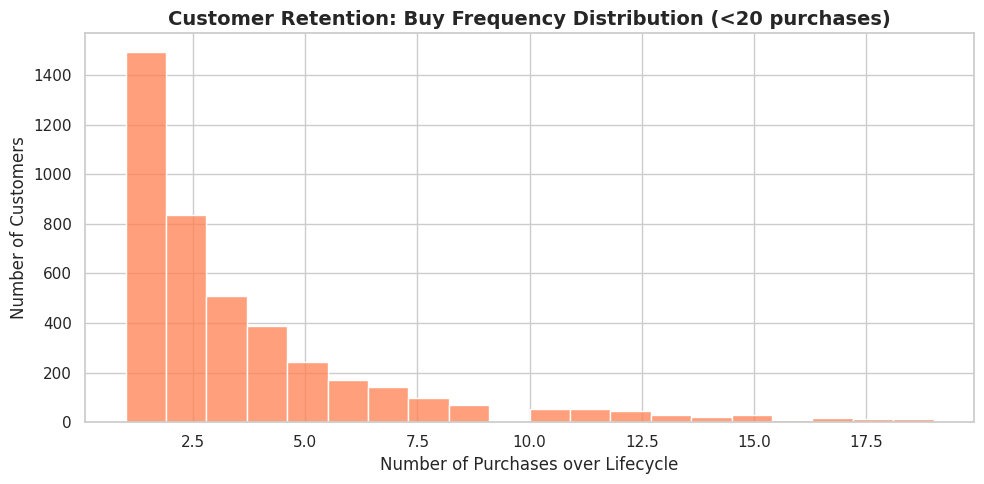

In [35]:
customer_freq = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()
print("Customer Purchase Frequency")
print(customer_freq.head(10))
print()

plt.figure(figsize=(10, 5))
sns.histplot(customer_freq[customer_freq < 20], bins=20, kde=False, color='coral')
plt.title('Customer Retention: Buy Frequency Distribution (<20 purchases)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Purchases over Lifecycle')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### Business Thinking: VIP Customer Identification (RFM Analysis)
**What you are seeing:** We calculate three metrics for every customer:
- **Recency:** How many days since they last bought? (Lower is better)
- **Frequency:** How many times have they bought? (Higher is better)
- **Monetary:** How much have they spent? (Higher is better)

**Why it is useful:** We then use a Machine Learning algorithm (`K-Means Clustering`) to automatically separate average customers from **VIP "Whales"**. Knowing who your VIPs are allows you to send them exclusive discounts, ensuring they don't migrate to competitors.


In [36]:
max_date = df_clean['InvoiceDate'].max()
print(f"Max Date: {max_date}")
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (max_date - x.max()).days, # RecentUsed
    'InvoiceNo': 'nunique',                             # Frequency
    'Revenue': 'sum'                                    # Monetary
}).reset_index()
print("Recency, Frequency, and Monetary")

rfm.rename(columns={'InvoiceDate': 'RecentUsed', 'InvoiceNo': 'Frequency', 'Revenue': 'Monetary'}, inplace=True)
print(rfm.head(10))
print()

# Identify Cluster Types
scaler_rfm = StandardScaler()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
rfm['Account_Type_Cluster'] = kmeans.fit_predict(scaler_rfm.fit_transform(rfm[['RecentUsed', 'Frequency', 'Monetary']]))
print("Customer Account Types")
print(rfm.head())
print()

vip_rev = rfm[rfm['Account_Type_Cluster'] == 1]['Monetary'].sum()
total_rev = rfm['Monetary'].sum()
print(f"Business Insight: The VIP Cluster generates £{vip_rev:,.0f} of the £{total_rev:,.0f} overall revenue!")


Max Date: 2011-12-09 12:50:00
Recency, Frequency, and Monetary
   CustomerID  RecentUsed  Frequency  Monetary
0     12346.0         325          1  77183.60
1     12347.0           1          7   4310.00
2     12348.0          74          4   1797.24
3     12349.0          18          1   1757.55
4     12350.0         309          1    334.40
5     12352.0          35          8   2506.04
6     12353.0         203          1     89.00
7     12354.0         231          1   1079.40
8     12355.0         213          1    459.40
9     12356.0          22          3   2811.43

Customer Account Types
   CustomerID  RecentUsed  Frequency  Monetary  Account_Type_Cluster
0     12346.0         325          1  77183.60                     0
1     12347.0           1          7   4310.00                     0
2     12348.0          74          4   1797.24                     0
3     12349.0          18          1   1757.55                     0
4     12350.0         309          1    334.40     

## Machine Learning: Predicting the Future
**What you are seeing:** We divide the data. We study a customer's history from Jan to Oct, and we try to predict their behavior in November.
**Why it is useful:**
- **Linear/Polynomial Regression:** Predicts *exactly how much money* a returning customer will spend next month.
- **Logistic Regression:** Predicts *whether they will return at all* (Churn Probability).
By predicting churn, the marketing team can preemptively send a "Please come back, here's 10% off" email BEFORE the customer actually leaves forever.


In [37]:
# (Sine/Cosine mapping)
df_clean['Month_Sin'] = np.sin(2 * np.pi * df_clean['Month_Num'] / 12.0)
df_clean['Month_Cos'] = np.cos(2 * np.pi * df_clean['Month_Num'] / 12.0)

# Pre-November Data vs. November Target
pre_nov = df_clean[df_clean['Month_Num'] < 11]
ml_features = pre_nov.groupby('CustomerID').agg({
    'Revenue': ['sum', 'mean'],
    'InvoiceNo': 'nunique',
    'Month_Sin': 'mean', 'Month_Cos': 'mean'
}).reset_index()
print("PRE-November Data")
print()
ml_features.columns = ['CustomerID', 'Hist_Total_Rev', 'Hist_Avg_Rev', 'Hist_Frequency', 'Avg_Month_Sin', 'Avg_Month_Cos']
print(ml_features.head(5))
print()

# Logarithmic Transformation
ml_features['Log_Hist_Rev'] = np.log1p(ml_features['Hist_Total_Rev'])
ml_features['Log_Hist_Avg_Rev'] = np.log1p(ml_features['Hist_Avg_Rev'])

nov = df_clean[df_clean['Month_Num'] == 11].groupby('CustomerID')['Revenue'].sum().reset_index()
nov.rename(columns={'Revenue': 'Target_Nov_Revenue'}, inplace=True)
print("November Target Revenue")
print(nov.head(5))
print()

ml_df = pd.merge(ml_features, nov, on='CustomerID', how='left')
#Missing Values
ml_df['Target_Nov_Revenue'] = ml_df['Target_Nov_Revenue'].fillna(0)

# Target preparation
ml_df['Is_Retained'] = (ml_df['Target_Nov_Revenue'] > 0).astype(int) # Logistic Target
ml_df['Log_Target_Revenue'] = np.log1p(ml_df['Target_Nov_Revenue']) # Linear/Poly Target

reg_df = ml_df[ml_df['Is_Retained'] == 1].copy()
# X and y vectors
X_reg = reg_df[['Log_Hist_Rev', 'Log_Hist_Avg_Rev', 'Hist_Frequency', 'Avg_Month_Sin', 'Avg_Month_Cos']]
y_reg = reg_df['Log_Target_Revenue']

X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_reg_tr_s = scaler.fit_transform(X_reg_tr)
X_reg_te_s = scaler.transform(X_reg_te)

# ---  LINEAR REGRESSION ---
lin_model = LinearRegression()
lin_model.fit(X_reg_tr_s, y_reg_tr)
lin_r2 = r2_score(y_reg_te, lin_model.predict(X_reg_te_s))
print(f"Linear Regression Forecast R²: {lin_r2:.4f} (Predicts spending amount)")

# --- POLYNOMIAL REGRESSION ---
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_model = LinearRegression()
poly_model.fit(poly.fit_transform(X_reg_tr_s), y_reg_tr)
poly_r2 = r2_score(y_reg_te, poly_model.predict(poly.transform(X_reg_te_s)))
print(f"Polynomial Regression Forecast R²: {poly_r2:.4f} (More advanced spend prediction)")

# --- LOGISTIC REGRESSION ---
X_clf = ml_df[['Log_Hist_Rev', 'Log_Hist_Avg_Rev', 'Hist_Frequency', 'Avg_Month_Sin', 'Avg_Month_Cos']]
y_clf = ml_df['Is_Retained']
X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
scale_clf = StandardScaler()

log_model = LogisticRegression(class_weight='balanced')
log_model.fit(scale_clf.fit_transform(X_clf_tr), y_clf_tr)
auc = roc_auc_score(y_clf_te, log_model.predict_proba(scale_clf.transform(X_clf_te))[:, 1])
print(f"Logistic Regression AUC-ROC: {auc:.4f} (Predicts likelihood of churn)")


PRE-November Data

   CustomerID  Hist_Total_Rev  Hist_Avg_Rev  Hist_Frequency  Avg_Month_Sin  \
0     12346.0        77183.60  77183.600000               1       0.500000   
1     12347.0         3373.39     24.095643               5      -0.174794   
2     12348.0          904.44     64.602857               3       0.309295   
3     12350.0          334.40     19.670588               1       0.866025   
4     12352.0         2194.31     31.347286               7       0.057005   

   Avg_Month_Cos  
0       0.866025  
1       0.054391  
2       0.192582  
3       0.500000  
4       0.107143  

November Target Revenue
   CustomerID  Target_Nov_Revenue
0     12349.0             1757.55
1     12352.0              311.73
2     12356.0               58.35
3     12357.0             6207.67
4     12362.0              477.94

Linear Regression Forecast R²: 0.4549 (Predicts spending amount)
Polynomial Regression Forecast R²: 0.4617 (More advanced spend prediction)
Logistic Regression AUC-ROC:

### 🎯 Conclusion
This pipeline has successfully demonstrated how to ingest massive datasets, clean anomalies, extract business intelligence visualizations, segment VIP customers through clustering, and mathematically predict future revenue metrics.

**Understanding these metrics converts simple code into powerful business strategy.**
